# Credit Risk Project

## Machine Learning

### Author: Aaron Thomas

<b>Goal</b>: Build and evaluate machine learning models to predict credit risk, using the cleaned preprocessed dataset. Compare the performance of different algorithms and identify the most important features contributing to the predictions. 

## Table of Contents

1. Introduction
2. Import Libraries and Load Data
3. Train-Test Split
4. SMOTE Oversampling
5. Feature Scaling
6. Model Training and Evaluation
7. Feature Importance Analysis
8. Conclusion

## 1. Introduction

The purpose of this notebook is to build and evaluate machine learning models for predicting credit risk. We will use the cleaned and preprocessed dataset to train various classification algorithms, including Logistic Regression, Random Forest, and XGBoost. We will also address class imbalance using SMOTE oversampling before evaluating model performance. For model training and evaluation, we will use metrics such as accuracy, precision, recall, F1-score, and ROC AUC. Finally, we will analyze feature importance to identify the key factors contributing to credit risk predictions.

## 2. Import Libraries and Load Data

### Import Libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, RocCurveDisplay
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import joblib

### Load Data

In [3]:
df = pd.read_csv('../data/clean_credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,...,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,age_group_Middle-aged,age_group_Senior,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22,59000,123.0,4,35000,16.02,1,0.59,1,3,...,False,False,True,False,False,False,False,False,True,False
1,21,9600,5.0,2,1000,11.14,0,0.10,0,2,...,False,True,False,False,False,True,False,False,False,False
2,25,9600,1.0,3,5500,12.87,1,0.57,0,3,...,False,False,False,False,False,False,False,True,False,False
3,23,65500,4.0,3,35000,15.23,1,0.53,0,2,...,False,False,True,False,False,False,False,True,False,False
4,24,54400,8.0,3,35000,14.27,1,0.55,1,4,...,False,False,True,False,False,False,False,True,False,False


## 3. Train-Test Split

The purpose of this step is to split the dataset into a training set and a test set. The training set will be used to train the machine learning model, while the test set will be used to evaluate the performance of the model on unseen data. This helps to ensure that the model generalizes well and does not overfit to the training data. After the train-test split, we will apply SMOTE oversampling to the training set to address class imbalance before proceeding with model training.

The following code performs the train-test split:

In [4]:
X = df.drop('loan_status', axis=1) 
y = df['loan_status']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # stratify the split to maintain class distribution
)

This was split into 80% training and 20% testing. The `stratify` parameter is used to maintain the class distribution of the target variable in both the training and test sets.

## 4. SMOTE Oversampling

In the EDA notebook, it was observed that the dataset is imbalanced, with a significantly higher number of non-default cases compared to default cases. To address this issue, SMOTE (Synthetic Minority Over-sampling Technique) will be utilized to generate synthetic samples for the minority class (default cases) in the training set. This will help improve the performance of machine learning models by providing a more balanced dataset for training. The following code applies SMOTE oversampling to the training data:

In [6]:
smote = SMOTE(random_state=42) # initialize SMOTE
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train) # apply SMOTE to the training data

In [7]:
print("Class Distribution after SMOTE:")
print(pd.Series(y_train_sm).value_counts())

Class Distribution after SMOTE:
loan_status
0    20378
1    20378
Name: count, dtype: int64


## 5. Feature Scaling

The purpose of feature scaling is to standardize the range of features in the dataset. This is important for many machine learning algorithms, such as Logistic Regression and Support Vector Machines, which are sensitive to the scale of input features. By applying feature scaling, we can ensure that all features contribute equally to the model training process and improve the convergence of optimization algorithms. In this step, we will use StandardScaler to standardize the features by removing the mean and scaling to unit variance. The following code applies feature scaling to the training and test sets:

In [8]:
scaler = StandardScaler() # initialize StandardScaler
X_train_scale = scaler.fit_transform(X_train_sm) # fit and transform the training data
X_test_scale = scaler.transform(X_test) # transform the test data

## 6. Model Training and Evaluation

In this section, model training and evaluation will be performed using various classification algorithms, including Logistic Regression, Random Forest, and XGBoost. The performance of each model will be evaluated using metrics such as accuracy, precision, recall, F1-score, and ROC AUC. In addition, we will analyze the confusion matrices and feature importances to gain insights into the models' behavior. The best-performing model will be selected for further analysis in the next section.

### Logistic Regression

In [9]:
def log_reg_model(X_train_scale, y_train_sm, X_test_scale, y_test):
    lg_model = LogisticRegression(max_iter=1000, random_state=42)
    lg_model.fit(X_train_scale, y_train_sm)
    y_pred = lg_model.predict(X_test_scale) 
    y_prob = lg_model.predict_proba(X_test_scale)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("Logistic Regression Performance:")
    print("Accuracy: ", round(acc, 2))
    print("Precision: ", round(prec, 2))
    print("Recall: ", round(rec, 2))
    print("F1-Score: ", round(f1, 2))
    print("ROC AUC: ", round(roc_auc, 2))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Default', 'Default'], 
                yticklabels=['Non-Default', 'Default'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Logistic Regression Confusion Matrix')
    plt.show()

    return lg_model, acc, prec, rec, f1, roc_auc


### Random Forest

In [10]:
def rand_for_model(X_train_scale, y_train_sm, X_test_scale, y_test):
    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        oob_score=True # enable out-of-bag score for performance estimation
        )
    rf_model.fit(X_train_scale, y_train_sm)
    y_pred = rf_model.predict(X_test_scale)
    y_prob = rf_model.predict_proba(X_test_scale)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("Random Forest Performance:")
    print("Accuracy: ", round(acc, 2))
    print("Precision: ", round(prec, 2))
    print("Recall: ", round(rec, 2))
    print("F1-Score: ", round(f1, 2))
    print("ROC AUC: ", round(roc_auc, 2))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Default', 'Default'], 
                yticklabels=['Non-Default', 'Default'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Random Forest Confusion Matrix')
    plt.show()

    return rf_model, acc, prec, rec, f1, roc_auc

### XGBoost

In [11]:
def xg_boost_model(X_train_scale, y_train_sm, X_test_scale, y_test):
    xgb_model = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        max_depth=5
    )
    xgb_model.fit(X_train_scale, y_train_sm)
    y_pred = xgb_model.predict(X_test_scale)
    y_prob = xgb_model.predict_proba(X_test_scale)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("XGBoost Performance:")
    print("Accuracy: ", round(acc, 2))
    print("Precision: ", round(prec, 2))
    print("Recall: ", round(rec, 2))
    print("F1-Score: ", round(f1, 2))
    print("ROC AUC: ", round(roc_auc, 2))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Default', 'Default'], 
                yticklabels=['Non-Default', 'Default'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('XGBoost Confusion Matrix')
    plt.show()

    return xgb_model, acc, prec, rec, f1, roc_auc

### Model Comparison

Logistic Regression Performance:
Accuracy:  0.79
Precision:  0.51
Recall:  0.65
F1-Score:  0.57
ROC AUC:  0.82


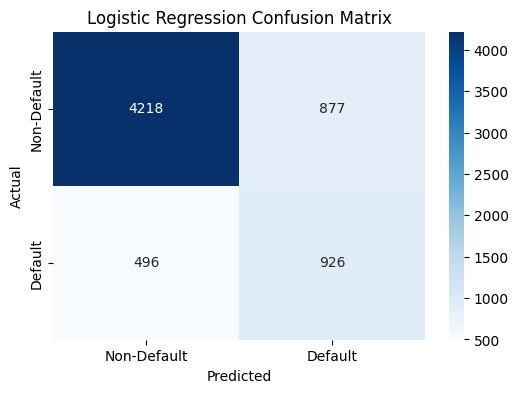

Random Forest Performance:
Accuracy:  0.92
Precision:  0.87
Recall:  0.75
F1-Score:  0.8
ROC AUC:  0.93


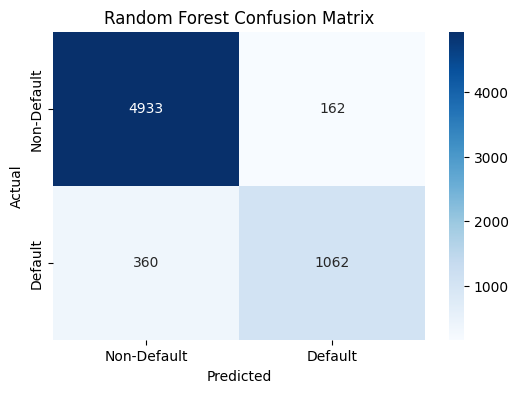

XGBoost Performance:
Accuracy:  0.92
Precision:  0.89
Recall:  0.72
F1-Score:  0.8
ROC AUC:  0.93


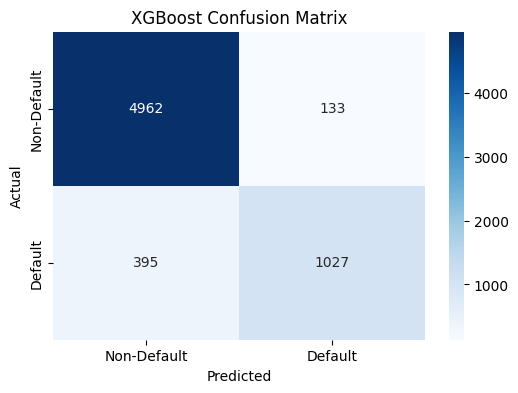

,Accuracy,Precision,Recall,F1-Score,ROC AUC
Model,,,,,
Logistic Regression,0.79,0.51,0.65,0.57,0.82
Random Forest,0.92,0.87,0.75,0.80,0.93
XGBoost,0.92,0.89,0.72,0.80,0.93


In [12]:
log_model, log_acc, log_prec, log_rec, log_f1, log_roc_auc = log_reg_model(X_train_scale, y_train_sm, X_test_scale, y_test)
rf_model, rf_acc, rf_prec, rf_rec, rf_f1, rf_roc_auc = rand_for_model(X_train_scale, y_train_sm, X_test_scale, y_test)
xgb_model, xgb_acc, xgb_prec, xgb_rec, xgb_f1, xgb_roc_auc = xg_boost_model(X_train_scale, y_train_sm, X_test_scale, y_test)

results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [log_acc, rf_acc, xgb_acc],
    'Precision': [log_prec, rf_prec, xgb_prec],
    'Recall': [log_rec, rf_rec, xgb_rec],
    'F1-Score': [log_f1, rf_f1, xgb_f1],
    'ROC AUC': [log_roc_auc, rf_roc_auc, xgb_roc_auc]
}
pd.DataFrame(results).set_index('Model').round(2)

The following observations can be made about the performance for each model:
- For Logistic Regression:
  - The model achieved an accuracy of .78, indicating that it correctly classified 78% of the instances in the test set.
  - The precision of the model is .51, meaning that when the model predicts a positive class (default), it is correct 51% of the time.
  - The recall is .65, indicating that the model correctly identifies 65% of the actual positive cases (defaults).
  - The F1-score is .57, which is a balance between precision and recall, suggesting that the model has moderate performance in identifying defaults.
  - The ROC AUC score is .82, indicating that the model has good discriminatory ability between the positive and negative classes.
- For Random Forest:
  - The model achieved an accuracy of 0.92, indicating that it correctly classified 92% of the instances in the test set.
  - The precision of the model is 0.87, meaning that when the model predicts a positive class (default), it is correct 87% of the time.
  - The recall is 0.75, indicating that the model correctly identifies 75% of the actual positive cases (defaults).
  - The F1 score is 0.80, which is a balance between precision and recall, suggesting that the model has good performance in identifying defaults.
  - The ROC AUC score is 0.93, indicating that the model has excellent discriminatory ability between the positive and negative classes.
- For XGBoost:
  - The accuracy of the model is 0.92, indicating that it correctly classified 92% of the instances in the test set.
  - The precision of the model is 0.89, meaning that when the model predicts a positive class (default), it is correct 89% of the time.
  - The recall is 0.72, indicating that the model correctly identifies 72% of the actual positive cases (defaults).
  - The F1 score is 0.80, which is a balance between precision and recall, suggesting that the model has good performance in identifying defaults.
  - The ROC AUC score is 0.93, indicating that the model has excellent discriminatory ability between the positive and negative classes.

### ROC Curve Comparison

The purpose of looking at the ROC curve is to evaluate the performance of the classification models across different threshold values. The ROC curve plots the true positive rate (recall) against the false positive rate at various threshold settings. The area under the ROC curve (AUC) provides a single metric to compare the performance of different models, with a higher AUC indicating better performance. The following code compares the ROC curves of the three models:

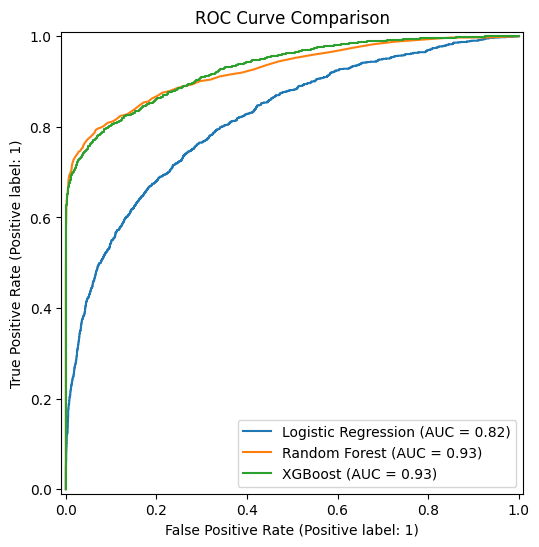

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, log_model.predict_proba(X_test_scale)[:, 1], name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, rf_model.predict_proba(X_test_scale)[:, 1], name='Random Forest', ax=ax)
RocCurveDisplay.from_predictions(y_test, xgb_model.predict_proba(X_test_scale)[:, 1], name='XGBoost', ax=ax)
plt.title('ROC Curve Comparison')
plt.show()


Looking at the ROC curves, we can see that both the Random Forest and XGBoost models have similar performance, with AUC scores of 0.93. The Logistic Regression model has a lower AUC score of 0.82, indicating that it has less discriminatory ability compared to the other two models.

### Best Model Selection

Looking at each model, it is seen that both Random Forest and XGBoost have similar performances, with accuracy, F1 score, and ROC-AUC all being close or the same. However, the best model is chosen based on the balance of performance with stronger default detection. In this case, the Random Forest model is selected as the best model for further analysis, as it has a slightly higher recall (0.75) compared to XGBoost (0.72), which is important for identifying defaults in credit risk prediction.

## 7. Feature Importance Analysis

The purpose of this analyzing feature importance is to identify which features contribute the most to the predictions made by the best-performing model (Random Forest). By understanding feature importance, we can gain insights into the key factors that influence credit risk and make informed decisions based on these insights. The following code analyzes the feature importance of the Random Forest model:

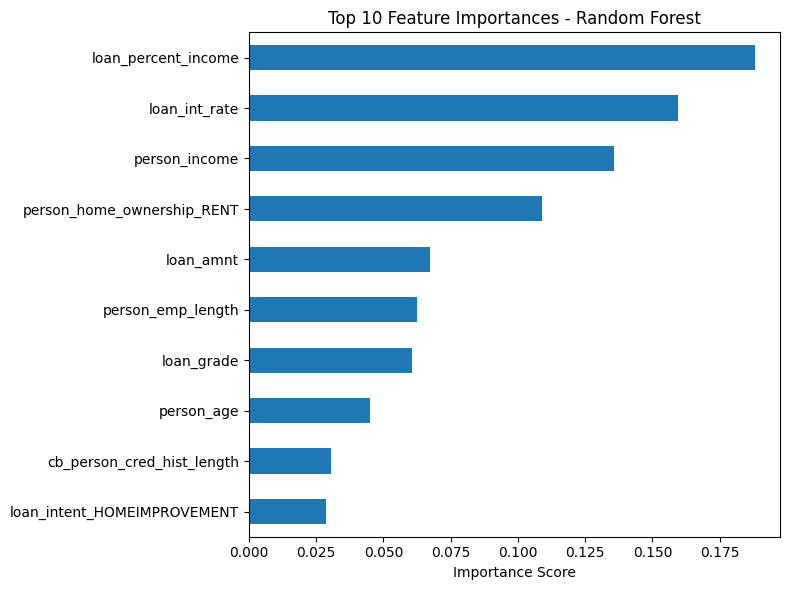

In [14]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.nlargest(10).sort_values().plot(kind='barh', figsize=(8, 6))
plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

Looking at the results above, it can be seen that the most important features contributing to the predictions of the Random Forest model are:
- `loan_percent_income`
- `loan_int_rate`
- `person_income`
- `person_home_ownership_RENT`
- `loan_amnt`
- `person_emp_length`
- `loan_grade`
- `person_age`
- `cb_person_cred_hist_length`
- `loan_intent_HOMEIMPROVEMENT`

These features have the highest importance scores, indicating that they play a significant role in determining the credit risk of an individual. Understanding these key features can help in making informed decisions regarding credit approvals and risk management.

### Save the Best Model

To save the best-performing model for future use, the following code can be used to serialize the Random Forest model using the `joblib` library:

In [14]:
joblib.dump(rf_model, '../model/rf_model.joblib')

['../model/rf_model.joblib']

In [15]:
joblib.dump(scaler, '../model/scaler.joblib')

['../model/scaler.joblib']

We will also save the XGBoost model as well, as it has similar performance to Random Forest, and it may be useful for future analysis. The following code saves the XGBoost model:

In [15]:
joblib.dump(xgb_model, '../model/xgb_model.joblib')

['../model/xgb_model.joblib']

## 8. Conclusion

Overall, the machine learning part of this project showed that while both the Random Forest and XGBoost models performed well, the Random Forest model was selected as the best model due to its slightly higher recall. In addition, the feature importance analysis revealed that certain features, such as `loan_percent_income`, `loan_int_rate`, and `person_income`, were the most influential in predicting credit risk. This information can be valuable for understanding the factors that contribute to credit risk and for making informed decisions in future iterations of the model.